In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import sys
sys.path.append('../..')
from common.style import PRIMARY, PRIMARY_DARK, ACCENT, ACCENT_LIGHT, AXIS_COLOR, GRID_COLOR

df = pd.read_excel('../../jhani_pandit_dataset/Fitness_Survey__Responses_clean.xlsx')

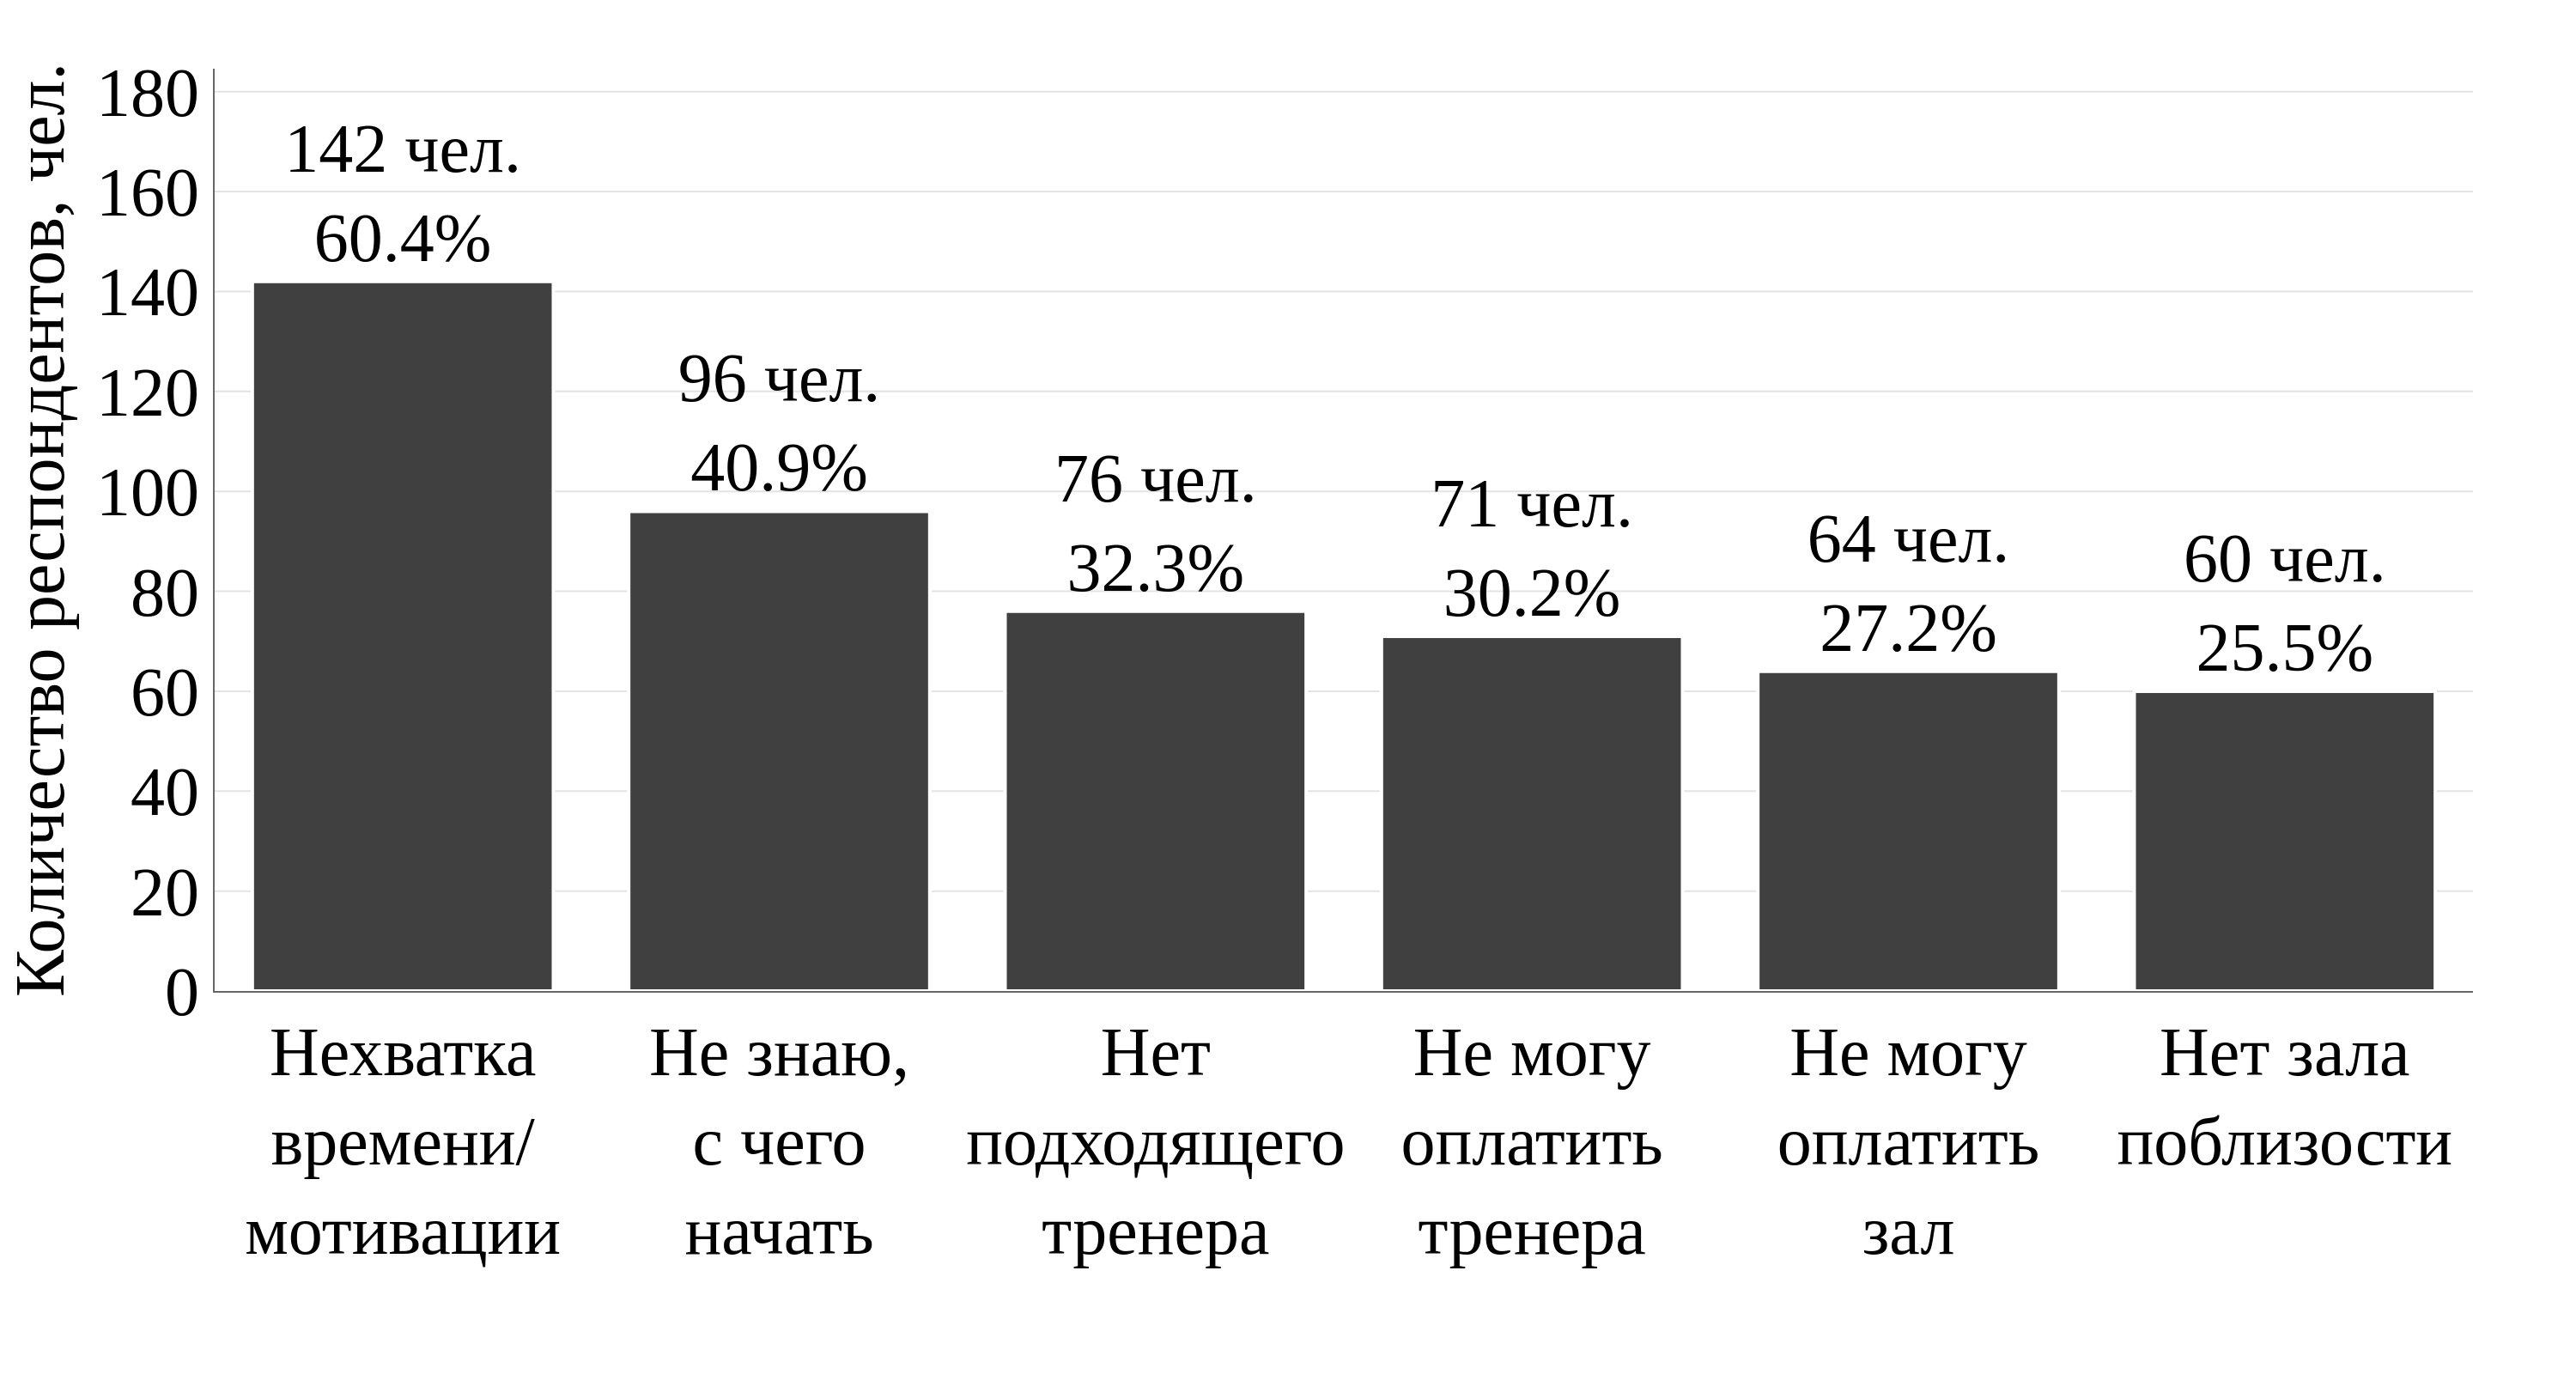

In [2]:
routine_barriers = [
    col for col in df.columns
    if '(routine)' in col
    and col not in ['Barriers_routine', 'Other (routine)', 'No barriers (routine)']
]

routine_data = (
    df[routine_barriers]
    .sum()
    .sort_values(ascending=False)
)

routine_percent = (routine_data / len(df) * 100).round(1)

barriers_ru = {
    "Lack of motivation / time (routine)": "Нехватка<br>времени/<br>мотивации",
    "Don't know how to start (routine)": "Не знаю,<br>с чего<br>начать",
    "Can't find trainer/expert (routine)": "Нет<br>подходящего<br>тренера",
    "Can't afford personal trainer (routine)": "Не могу<br>оплатить<br>тренера",
    "Can't afford gym/classes (routine)": "Не могу<br>оплатить<br>зал",
    "No gym/classes nearby (routine)": "Нет зала<br>поблизости"
}

labels = [barriers_ru.get(x, x) for x in routine_data.index]

fig = go.Figure(data=[go.Bar(
    x=labels,
    y=routine_data.values,
    text=[
        f'{count} чел.<br>{pct}%'
        for count, pct in zip(routine_data.values, routine_percent.values)
    ],
    textposition='outside',
    textfont=dict(
        size=40,
        color='#000000',
        family='Times New Roman'
    ),
    marker=dict(
        color=PRIMARY,
        line=dict(color='white', width=2)
    ),
    hovertemplate='<b>%{x}</b><br>Количество: %{y} чел.<extra></extra>'
)])

fig.update_layout(
    showlegend=False,
    paper_bgcolor='white',
    plot_bgcolor='white',
    font=dict(
        family='Times New Roman',
        size=40,
        color='#000000'
    ),
    xaxis=dict(
        title='',
        showgrid=False,
        tickfont=dict(size=40),
        linecolor=AXIS_COLOR,
        linewidth=1,
        tickangle=0
    ),
    yaxis=dict(
        title='Количество респондентов, чел.',
        titlefont=dict(size=41),
        tickfont=dict(size=40),
        showgrid=True,
        gridcolor=GRID_COLOR,
        zeroline=False,
        linecolor=AXIS_COLOR,
        linewidth=1,
        range=[0, routine_data.max() * 1.3]
    ),
    margin=dict(
        l=60,
        r=60,
        t=40,
        b=180
    ),
    width=1500,
    height=800
)

fig.show()